# Alternative Sentiment Scores

Calculate FinBERT sentiment probabilities for the filtered AAPL-only, high-information news rows. Reuse a cached artifact only when its ordered news IDs exactly match the input.

## Process the Data

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.data_preprocessing.alternative_sentiment_scores import (
    score_sentiment_features,
)

PROJECT_ROOT = Path.cwd().resolve().parents[1]
data_root = PROJECT_ROOT / "data/research_data/alternative"
period = "2025-01-01_2025-12-31"
news_path = data_root / "data" / f"aapl_{period}.parquet"
sentiment_path = data_root / "features" / f"aapl_finbert_sentiment_scores_{period}.parquet"
alternative_data = pd.read_parquet(news_path)
score_columns = [
    "sentiment_positive", "sentiment_negative",
    "sentiment_neutral", "sentiment_score",
]
cache_matches_input = False
if sentiment_path.is_file():
    sentiment_features = pd.read_parquet(sentiment_path)
    cache_matches_input = (
        "id" in sentiment_features
        and sentiment_features["id"].tolist() == alternative_data["id"].tolist()
    )
if not cache_matches_input:
    sentiment_features = score_sentiment_features(
        alternative_data,
        batch_size=16,
    )
    sentiment_path.parent.mkdir(parents=True, exist_ok=True)
    sentiment_features.to_parquet(sentiment_path, index=False)
sentiment_path

PosixPath('/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/research_data/alternative/features/aapl_finbert_sentiment_scores_2025-01-01_2025-12-31.parquet')

## Take a Quick Look at the Data Structure

In [8]:
sentiment_features.head()

,id,headline,source,url,summary,created_at,updated_at,symbols,author,content,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_score
0,42755273,EXCLUSIVE: Top 20 Most-Searched Tickers On Ben...,benzinga,https://www.benzinga.com/trading-ideas/25/01/4...,Each trading day features hundreds of headline...,2025-01-01 14:15:41+00:00,2025-01-01 14:15:42+00:00,"AAPL,AMD,AVGO,BTCUSD,CLSK,DELL,DJT,LAES,LLY,MS...",Chris Katje,<p>Each trading day features hundreds of headl...,0.024251,0.027078,0.948670,-0.002827
1,42755470,Competitor Analysis: Evaluating Apple And Comp...,benzinga,https://www.benzinga.com/insights/news/25/01/4...,,2025-01-01 15:00:27+00:00,2025-01-01 15:00:28+00:00,AAPL,Benzinga Insights,<p>In the ever-evolving and intensely competit...,0.056779,0.021039,0.922182,0.035741
2,42756523,10 Information Technology Stocks With Whale Al...,benzinga,https://www.benzinga.com/insights/options/25/0...,,2025-01-01 17:35:14+00:00,2025-01-01 17:35:15+00:00,"AAPL,DELL,INTC,MSFT,MSTR,MU,NVDA,RGTI,SOUN,WULF",Benzinga Insights,<p>This whale alert can help traders discover ...,0.083199,0.030645,0.886155,0.052554
3,42756619,"Warren Buffett Says Buy S&P 500, But This Tech...",benzinga,https://www.benzinga.com/markets/25/01/4275661...,Venture capitalist Chamath Palihapitiya has qu...,2025-01-01 18:00:19+00:00,2025-01-01 18:00:19+00:00,"AAPL,MSFT,NVDA",Bibhu Pattnaik,<p>Venture capitalist <strong>Chamath Palihapi...,0.024122,0.842134,0.133743,-0.818012
4,42758055,"Tim Cook, Mark Zuckerberg, Elon Musk, And More...",benzinga,https://www.benzinga.com/25/01/42758055/tim-co...,"Top tech CEOs like Tim Cook, Sundar Pichai, El...",2025-01-02 02:28:01+00:00,2025-01-02 02:28:02+00:00,"AAPL,GOOG,GOOGL,META,TSLA",Ananya Gairola,"<p>As the world stepped into 2025, some of the...",0.801017,0.013107,0.185875,0.787910


In [9]:
sentiment_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id                  3309 non-null   int64              
 1   headline            3309 non-null   str                
 2   source              3309 non-null   str                
 3   url                 3309 non-null   str                
 4   summary             3309 non-null   str                
 5   created_at          3309 non-null   datetime64[us, UTC]
 6   updated_at          3309 non-null   datetime64[us, UTC]
 7   symbols             3309 non-null   str                
 8   author              3309 non-null   str                
 9   content             3309 non-null   str                
 10  sentiment_positive  3309 non-null   float64            
 11  sentiment_negative  3309 non-null   float64            
 12  sentiment_neutral   3309 non-null   float64  

In [10]:
sentiment_features["source"].value_counts(dropna=False)

source
benzinga    3309
Name: count, dtype: int64

In [11]:
sentiment_features[score_columns].describe()

,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_score
count,3309.000000,3309.000000,3309.000000,3309.000000
mean,0.315337,0.258901,0.425762,0.056437
std,0.351758,0.366116,0.371321,0.614548
min,0.006306,0.006413,0.011137,-0.968094
25%,0.037042,0.017349,0.047585,-0.375547
50%,0.107106,0.036030,0.304004,0.052554
75%,0.665094,0.491887,0.861272,0.598391
max,0.957611,0.975978,0.950844,0.941135


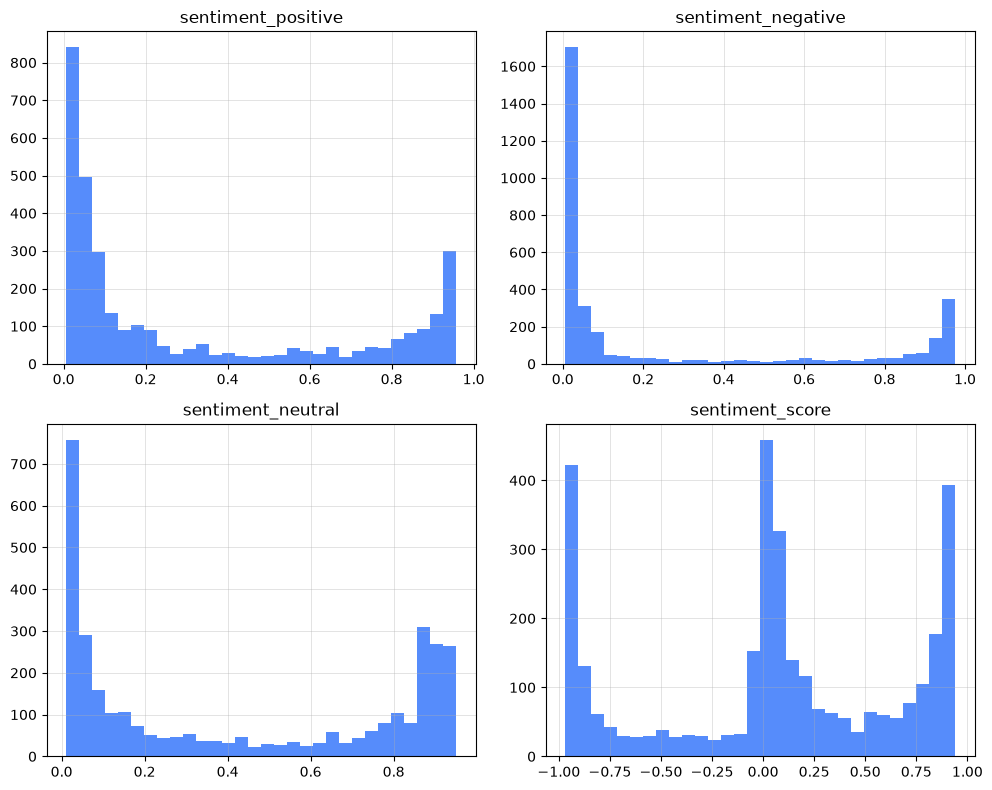

In [12]:
sentiment_features[score_columns].hist(bins=30, figsize=(10, 8))
plt.tight_layout()
plt.show()